# Fruit Vegetables Classification

In [30]:
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Exploraty Data Analysis and Data Preprocessing

In [3]:
fruit_folders = [
    'apple', 'banaana', 'grapes', 'kiwi', 'lemon', 'mango', 
    'orange', 'pear', 'pineaplle', 'pomegranate', 'watermelon']
vegetable_folders = [
    'beetroot', 'bell pepper', 'cabbage', 'capiscum', 'carrot', 
    'cauliflower', 'chili pepper', 'corn', 'cucumber', 'eggplant', 
    'garlic', 'ginger', 'jalepeno', 'lettuce', 'onion', 'paprika', 
    'peas', 'patato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 
    'sweetpatato', 'tomato', 'turnip'
]

In [4]:
img_path="Fruit-Vegetables-Dataset/train/"

In [8]:
img_list = []
label_list = []
for category in os.listdir(img_path):
    category_path = os.path.join(img_path, category)
    
    if os.path.isdir(category_path):
        if category in fruit_folders:
            label = "Fruit"
        elif category in vegetable_folders:
            label = "Vegetables"
        else:
            continue
            
        for img_file in os.listdir(category_path):
            img_list.append(os.path.join(category_path, img_file))
            label_list.append(label)

In [9]:
df=pd.DataFrame({"img":img_list,"label":label_list})

In [11]:
df.label.value_counts()

label
Vegetables    1874
Fruit          745
Name: count, dtype: int64

In [13]:
d=({"Fruit":1,"Vegetables":0})
df["label_encoded"]=df["label"].map(d)

In [14]:
df

,img,label,label_encoded
0,Fruit-Vegetables-Dataset/train/apple\Image_1.jpg,Fruit,1
1,Fruit-Vegetables-Dataset/train/apple\Image_10.jpg,Fruit,1
2,Fruit-Vegetables-Dataset/train/apple\Image_16.jpg,Fruit,1
3,Fruit-Vegetables-Dataset/train/apple\Image_17.jpg,Fruit,1
4,Fruit-Vegetables-Dataset/train/apple\Image_18.jpg,Fruit,1
...,...,...,...
2614,Fruit-Vegetables-Dataset/train/watermelon\Imag...,Fruit,1
2615,Fruit-Vegetables-Dataset/train/watermelon\Imag...,Fruit,1
2616,Fruit-Vegetables-Dataset/train/watermelon\Imag...,Fruit,1
2617,Fruit-Vegetables-Dataset/train/watermelon\Imag...,Fruit,1


In [21]:
x=[]
valid_indices=[]
for idx, img_path in enumerate(df["img"]):
    img = cv2.imread(str(img_path))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img=cv2.resize(img,(128,128))
        img=img/255.0 #normalize ediyoruz
        x.append(img)
        valid_indices.append(idx)

In [22]:
x = np.array(x)
y = np.array(df["label_encoded"].iloc[valid_indices])

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.20,stratify=y)

In [27]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=20,batch_size=64,verbose=1)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6945 - loss: 0.6670 - val_accuracy: 0.7156 - val_loss: 0.5889
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7174 - loss: 0.5650 - val_accuracy: 0.7176 - val_loss: 0.5416
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7251 - loss: 0.5309 - val_accuracy: 0.7424 - val_loss: 0.5325
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7403 - loss: 0.5060 - val_accuracy: 0.7672 - val_loss: 0.4834
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7551 - loss: 0.4826 - val_accuracy: 0.7863 - val_loss: 0.4650
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7790 - loss: 0.4513 - val_accuracy: 0.8053 - val_loss: 0.4475
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.8053 - loss: 0.4127 - val_accuracy: 0.7176 - val_loss: 0.5432
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8091 - loss: 0.4221 - val_accuracy: 0.7958 - val_loss:

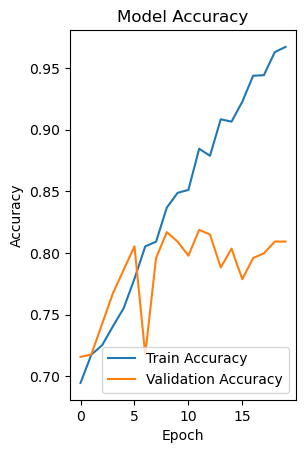

In [31]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step


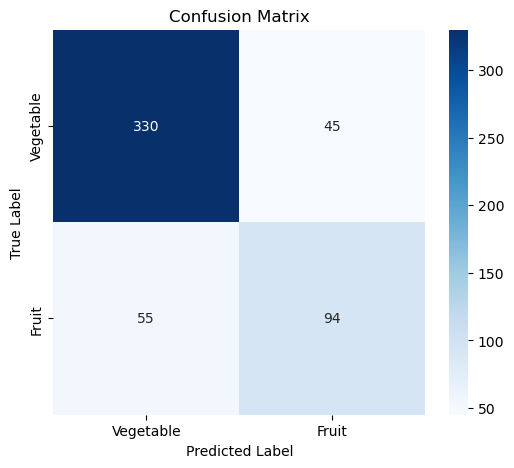

In [33]:
predictions = model.predict(x_test)

y_pred = (predictions > 0.5).astype(int)

class_names = ['Vegetable', 'Fruit']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [34]:
model.save("fruit_vegetable_model.keras")